In [ ]:
#PENGUMPULAN DATA

import pandas as pd

data = pd.read_csv("/content/dataset.csv")
print("sampel data: \n", data[:2])
print("\n")
print("jumlah baris dan kolom:", data.shape)
print("\n")
print("kolom dataset: \n", data.columns)
print("\n")


sampel data: 
   text_id annotators_id                                               text  \
0   1-Jan   ['7', '15']  Wajah Jurnalis Dibalut Perban Saat Melaporkan ...   
1  10-Jan   ['7', '15']  Elektabilitas Paslon 02 sebentar lagi terjun b...   

                                   initial_paragraph        topic  \
0  “️Jurnalis Hana Mahamed kembali tampil di tele...      UNKNOWN   
1                                                NaN  Disabilitas   

  is_noise_or_spam_text related_to_election_2024    toxicity   polarized  \
0            ['0', '0']               ['0', '0']  ['0', '0']  ['0', '0']   
1            ['0', '0']               ['1', '1']  ['0', '0']  ['1', '1']   

  profanity_obscenity threat_incitement_to_violence     insults  \
0          ['0', '0']                    ['0', '0']  ['0', '0']   
1          ['0', '0']                    ['0', '0']  ['0', '0']   

  identity_attack sexually_explicit  
0      ['0', '0']        ['0', '0']  
1      ['0', '0']        ['0', '0']

In [ ]:
#DATA PREPROCESSING 1 FEATURE SELECTION
print("\n#DATA PREPROCESSING 1 FEATURE SELECTION\n")
print("Kolom dataset sebelum feature selection:")
print(data.columns)

kolom_dipake = [
    'text',
    'toxicity',
    'polarized',
    'annotators_id',
    'is_noise_or_spam_text'
]

# Memfilter dataset
data = data[kolom_dipake]

# Menampilkan 3 data teratas untuk memastikan kolom sudah lengkap
print("\nKolom dataset setelah feature selection: ")
print(data.columns)
print(data[:3])


#DATA PREPROCESSING 1 FEATURE SELECTION

Kolom dataset sebelum feature selection:
Index(['text_id', 'annotators_id', 'text', 'initial_paragraph', 'topic',
       'is_noise_or_spam_text', 'related_to_election_2024', 'toxicity',
       'polarized', 'profanity_obscenity', 'threat_incitement_to_violence',
       'insults', 'identity_attack', 'sexually_explicit'],
      dtype='object')

Kolom dataset setelah feature selection: 
Index(['text', 'toxicity', 'polarized', 'annotators_id',
       'is_noise_or_spam_text'],
      dtype='object')
                                                text    toxicity   polarized  \
0  Wajah Jurnalis Dibalut Perban Saat Melaporkan ...  ['0', '0']  ['0', '0']   
1  Elektabilitas Paslon 02 sebentar lagi terjun b...  ['0', '0']  ['1', '1']   
2  Gini aja deh @KPU_ID usul aja nih. Gimana kalo...  ['1', '0']  ['0', '0']   

  annotators_id is_noise_or_spam_text  
0   ['7', '15']            ['0', '0']  
1   ['7', '15']            ['0', '0']  
2   ['7', '15']    

In [ ]:
#DATA PREPROCESSING - CLEANING DATA
print("DATA PREPROCESSING 2 - CLEANING DATA 1 - HAPUS SPAM")
#hapus spam
total_spam = 0

import ast
# 1. Konversi string "[0, 1]" menjadi list asli [0, 1]
# Gunakan ast.literal_eval agar Python paham itu adalah list, bukan teks biasa
def safe_to_list(val):
    if isinstance(val, str):
        try:
            return ast.literal_eval(val)
        except:
            return val
    return val

# Terapkan konversi pada kolom yang bermasalah
data['is_noise_or_spam_text'] = data['is_noise_or_spam_text'].apply(safe_to_list)

for i in range(len(data)):
    if '1' in str(data['is_noise_or_spam_text'][i]):
        total_spam += 1

print("\nJumlah data awal: ", len(data))
print("Jumlah data spam: ", total_spam)
print("jumlah data bukan spam: ", len(data) - total_spam)
print("\nMenghapus data spam...\n")
data = data[data['is_noise_or_spam_text'].apply(lambda x: '1' not in str(x))]
print("Jumlah data setelah penghapusan spam: ", len(data))


DATA PREPROCESSING 2 - CLEANING DATA 1 - HAPUS SPAM

Jumlah data awal:  28448
Jumlah data spam:  2884
jumlah data bukan spam:  25564

Menghapus data spam...

Jumlah data setelah penghapusan spam:  25564


In [ ]:
#DATA PREPROCESSING 2 - CLEANING DATA 2 - rasio 50:50
print("\nDATA PREPROCESSING 2 - CLEANING DATA 2 - HAPUS rasio 50:50\n")

import ast
# 1. Fungsi untuk mengubah string "[ '0', '1']" menjadi list asli [0, 1]
def clean_label_format(val):
    if isinstance(val, str):
        try:
            # ast.literal_eval akan mengubah string "[ '0', '1']" menjadi list ['0', '1']
            res = ast.literal_eval(val)
            # Ubah tiap elemen menjadi integer: [0, 1]
            return [int(i) for i in res]
        except:
            return val
    return val

# Terapkan pembersihan format pada kolom toxicity dan polarized
data['toxicity'] = data['toxicity'].apply(clean_label_format)
data['polarized'] = data['polarized'].apply(clean_label_format)


# 2. Fungsi untuk mengecek rasio 50% (Perfect Disagreement)
def is_50_percent(labels):
    if isinstance(labels, list) and len(labels) > 0:
        # Menghitung rasio angka 1
        angka_1 = 0
        for i in labels:
            if i == 1:
                angka_1 += 1
        ratio = angka_1 / len(labels)
        return ratio == 0.5
    return False

# 3. Eksekusi Penghapusan sesuai instruksimu
jumlah_awal = len(data)
print(f"Jumlah baris awal sebelum penghapusan rasio 50:50: {jumlah_awal}")

# Hapus jika salah satu kolom (toxicity ATAU polarized) memiliki rasio 50:50

data = data[~(data['toxicity'].apply(is_50_percent) |
              data['polarized'].apply(is_50_percent))].copy()

print(f"jumlah baris yang memiliki rasio 50:50: {jumlah_awal - len(data)}")
print(f"jumlah baris yang tidak memiliki rasio 50:50: {len(data)}")
print(f"\nPembersihan 50:50 dilakukan!\n")
print(f"jumlah baris data setelah dilakukan penghapusan rasio 50:50: {len(data)} baris")


DATA PREPROCESSING 2 - CLEANING DATA 2 - HAPUS rasio 50:50

Jumlah baris awal sebelum penghapusan rasio 50:50: 25564
jumlah baris yang memiliki rasio 50:50: 3285
jumlah baris yang tidak memiliki rasio 50:50: 22279

Pembersihan 50:50 dilakukan!

jumlah baris data setelah dilakukan penghapusan rasio 50:50: 22279 baris


In [ ]:
# PREPROCESSING DATA - CLEANING DATA 3 - MISSING VALUES
print("\nDATA PREPROCESSING 3 - CLEANING DATA 3 - HAPUS MISSING VALUES\n")

# 1. Cek missing values
print("Jumlah missing values sebelum penghapusan:")
print(data.isnull().sum())

# 2. Hapus baris dengan missing values
data = data.dropna()

print("Jumlah missing values setelah penghapusan:")
print(data.isnull().sum())
print(f"Jumlah baris data setelah dilakukan penghapusan missing values: {len(data)} baris")


DATA PREPROCESSING 3 - CLEANING DATA 3 - HAPUS MISSING VALUES

Jumlah missing values sebelum penghapusan:
text                     1
toxicity                 0
polarized                0
annotators_id            0
is_noise_or_spam_text    0
dtype: int64
Jumlah missing values setelah penghapusan:
text                     0
toxicity                 0
polarized                0
annotators_id            0
is_noise_or_spam_text    0
dtype: int64
Jumlah baris data setelah dilakukan penghapusan missing values: 22278 baris


In [ ]:
#NORMALISASI DATA - PENYERAGAMAN TEKS
print("\nNORMALISASI DATA - PENYERAGAMAN TEKS\n")

import re
# 1. Pastikan semua data di kolom text adalah string dan tangani nilai kosong (NaN)
data['text'] = data['text'].astype(str).fillna('')

# 2. Jalankan kembali fungsi normalisasi yang sudah diperbaiki
def data_normalization(text):
    # Tambahkan pengecekan tipe data untuk keamanan ekstra
    if not isinstance(text, str):
        text = str(text)

    # Ganti URL
    text = re.sub(r'http\S+|www\S+|https\S+', 'url', text, flags=re.MULTILINE)

    # Ganti Mention (@) menjadi username
    text = re.sub(r'@\w+', 'username', text)

    # Ganti Hashtag (#)
    text = re.sub(r'#\w+', 'hashtag', text)

    # Menghapus spasi berlebih
    text = re.sub(r'\s+', ' ', text).strip()

    return text

# Terapkan ke dataset
print("sampel data sebelum dilakukan normalisasi:")
for i, teks in enumerate(data['text'][:3]):
    print(f"Baris {i+1}: {teks}")
    print("-" * 50) # Garis pembatas agar mudah dibaca

data['text'] = data['text'].apply(data_normalization)
print("\nNormalisasi dilakukan!\n")

print("sampel data setelah dilakukan normalisasi:")
for i, teks in enumerate(data['text'][:3]):
    print(f"Baris {i+1}: {teks}")
    print("-" * 50) # Garis pembatas agar mudah dibaca



NORMALISASI DATA - PENYERAGAMAN TEKS

sampel data sebelum dilakukan normalisasi:
Baris 1: Wajah Jurnalis Dibalut Perban Saat Melaporkan Kondisi di Gaza 2023
--------------------------------------------------
Baris 2: Elektabilitas Paslon 02 sebentar lagi terjun bebas gara2 Gemoy, joget, susu gratis, makan gratis, politik dinasti, cacat hukum, Ijazah dan tidak hadir
--------------------------------------------------
Baris 3: Kristen, Hindu, Islam dapat perlakuan istimewa dari pak Anies Ncep ketar-ketir
--------------------------------------------------

Normalisasi dilakukan!

sampel data setelah dilakukan normalisasi:
Baris 1: Wajah Jurnalis Dibalut Perban Saat Melaporkan Kondisi di Gaza 2023
--------------------------------------------------
Baris 2: Elektabilitas Paslon 02 sebentar lagi terjun bebas gara2 Gemoy, joget, susu gratis, makan gratis, politik dinasti, cacat hukum, Ijazah dan tidak hadir
--------------------------------------------------
Baris 3: Kristen, Hindu, Islam dapa

In [ ]:
#DATA PREPROCESSING - normalisasi data 4 - EMOJI

import emoji

# 1. Buat filter: cari baris yang jumlah emojinya lebih dari 0
kondisi_ada_emoji = data['text'].apply(lambda x: emoji.emoji_count(str(x)) > 0)

# 2. Ambil data yang hanya berisi emoji, lalu pilih 3 secara acak
data_dengan_emoji = data[kondisi_ada_emoji].sample(3).copy()

# 3. Tampilkan hasilnya (Sebelum vs Sesudah)
for index, row in data_dengan_emoji.iterrows():
    teks_asli = row['text']

    # Lakukan demojize dan bersihkan karakternya
    teks_sesudah = emoji.demojize(str(teks_asli)).replace(":", " ").replace("_", " ")

    # Rapikan spasi ganda
    teks_sesudah = " ".join(teks_sesudah.split())

    print(f"--- sampel baris text_id: {data.loc[index, 'text_id'] if 'text_id' in data.columns else index} ---")
    print(f"SEBELUM : {teks_asli}")
    print(f"SESUDAH : {teks_sesudah}")
    print("-" * 50)

data['text'] = data['text'].apply(lambda x: emoji.demojize(str(x)).replace(":", " ").replace("_", " "))

--- sampel baris text_id: 2734 ---
SEBELUM : Hari ini ngasih makan anak baru di rumah sekaligus makan sate yg gendut gendut!! Nyam🫶🏻
SESUDAH : Hari ini ngasih makan anak baru di rumah sekaligus makan sate yg gendut gendut!! Nyam heart hands light skin tone
--------------------------------------------------
--- sampel baris text_id: 20707 ---
SEBELUM : Ha ha ha ha aku di block ama zionis israel satu ini🤣🤣🤣🤣
SESUDAH : Ha ha ha ha aku di block ama zionis israel satu ini rolling on the floor laughing rolling on the floor laughing rolling on the floor laughing rolling on the floor laughing
--------------------------------------------------
--- sampel baris text_id: 28381 ---
SEBELUM : CHINA MADEIN IN MADE FRAC HLEY Komponen Speaker Ashley Orange 155 pesanan Bosku WEL - FARLAN AUDIO di JAILOLO ✅️ Mantapp bosku💥💯👍 Buat teman-teman yang tertarik dengan produk ini langsung menghubungi nomor WA kami dan dapatkan harga spesial nya yaa👍👍👍 Toko Fortino Pro Audio & Lighting Jl.Piere Tendean no 17 Ko

In [ ]:
# 1. Simpan salinan 3 data pertama SEBELUM diubah
teks_sebelum = data['text'][:3].copy()

# 2. Lakukan normalisasi case folding pada seluruh data
data['text'] = data['text'].str.lower()

print("\nNormalisasi case folding dilakukan!\n")
print("Sampel data sebelum dan setelah dilakukan normalisasi case folding:")

# 3. Tampilkan perbandingan menggunakan salinan yang tadi disimpan
for i in range(3):
    print(f"Sebelum : {teks_sebelum.iloc[i]}")
    print(f"Sesudah : {data['text'].iloc[i]}")
    print("-" * 50)


Normalisasi case folding dilakukan!

Sampel data sebelum dan setelah dilakukan normalisasi case folding:
Sebelum : Wajah Jurnalis Dibalut Perban Saat Melaporkan Kondisi di Gaza 2023
Sesudah : wajah jurnalis dibalut perban saat melaporkan kondisi di gaza 2023
--------------------------------------------------
Sebelum : Elektabilitas Paslon 02 sebentar lagi terjun bebas gara2 Gemoy, joget, susu gratis, makan gratis, politik dinasti, cacat hukum, Ijazah dan tidak hadir
Sesudah : elektabilitas paslon 02 sebentar lagi terjun bebas gara2 gemoy, joget, susu gratis, makan gratis, politik dinasti, cacat hukum, ijazah dan tidak hadir
--------------------------------------------------
Sebelum : Kristen, Hindu, Islam dapat perlakuan istimewa dari pak Anies Ncep ketar-ketir
Sesudah : kristen, hindu, islam dapat perlakuan istimewa dari pak anies ncep ketar-ketir
--------------------------------------------------


In [ ]:
# FEATURE ENGINEERING - soft and hard labelling

#feature engineering

import pandas as pd
import numpy as np

def run_feature_engineering(df):
    # --- 1. Fungsi untuk Soft Label (Label Distribution Learning) ---
    def to_soft_label(labels):
        if isinstance(labels, list) and len(labels) > 0:
            total_anotator = len(labels)
            # Menghitung jumlah anotator yang memberikan nilai 1
            count_1 = sum(1 for i in labels if str(i) == '1')

            # Rasio untuk kelas positif (1) dan negatif (0)
            ratio_1 = round(count_1 / total_anotator, 2)
            ratio_0 = round(1.0 - ratio_1, 2)

            # Format output berupa distribusi probabilitas [prob_1, prob_0]
            # Contoh kasus: [1, 0, 0, 1] -> count_1 = 2, total = 4 -> [0.5, 0.5] (50:50)
            return [ratio_1, ratio_0]
        return [0.0, 1.0] # Default jika data kosong

    # --- 2. Fungsi untuk Hard Label (Majority Voting / Faktor Agregat) ---
    def to_hard_label(labels):
        if isinstance(labels, list) and len(labels) > 0:
            total_anotator = len(labels)
            count_1 = sum(1 for i in labels if str(i) == '1')

            # Majority Voting: Jika rasio nilai 1 lebih dari 50%, maka label final adalah 1
            # Jika seimbang atau lebih banyak 0, maka label final adalah 0
            return 1 if (count_1 / total_anotator) > 0.5 else 0
        return 0

    # --- 3. Eksekusi Pembuatan Kolom Baru ---
    # Membuat kolom Soft Label
    df['soft_toxic'] = df['toxicity'].apply(to_soft_label)
    df['soft_polarized'] = df['polarized'].apply(to_soft_label)

    # Membuat kolom Hard Label
    df['hard_toxic'] = df['toxicity'].apply(to_hard_label)
    df['hard_polarized'] = df['polarized'].apply(to_hard_label)

    return df

# Terapkan fungsi ke dataset kamu
data = run_feature_engineering(data)

# --- 4. Cek Hasil Perubahan ---
print("--- Sampel Data Hasil Feature Engineering ---")
print(data[['toxicity', 'soft_toxic', 'hard_toxic']].head())
print(data[['polarized', 'soft_polarized', 'hard_polarized']].head())
print("kolom data setelah feature engineering: \n", data.columns)

--- Sampel Data Hasil Feature Engineering ---
   toxicity  soft_toxic  hard_toxic
0    [0, 0]  [0.0, 1.0]           0
1    [0, 0]  [0.0, 1.0]           0
4    [0, 0]  [0.0, 1.0]           0
8    [0, 0]  [0.0, 1.0]           0
12   [0, 0]  [0.0, 1.0]           0
   polarized soft_polarized  hard_polarized
0     [0, 0]     [0.0, 1.0]               0
1     [1, 1]     [1.0, 0.0]               1
4     [1, 1]     [1.0, 0.0]               1
8     [0, 0]     [0.0, 1.0]               0
12    [0, 0]     [0.0, 1.0]               0
kolom data setelah feature engineering: 
 Index(['text', 'toxicity', 'polarized', 'annotators_id',
       'is_noise_or_spam_text', 'soft_toxic', 'soft_polarized', 'hard_toxic',
       'hard_polarized'],
      dtype='object')


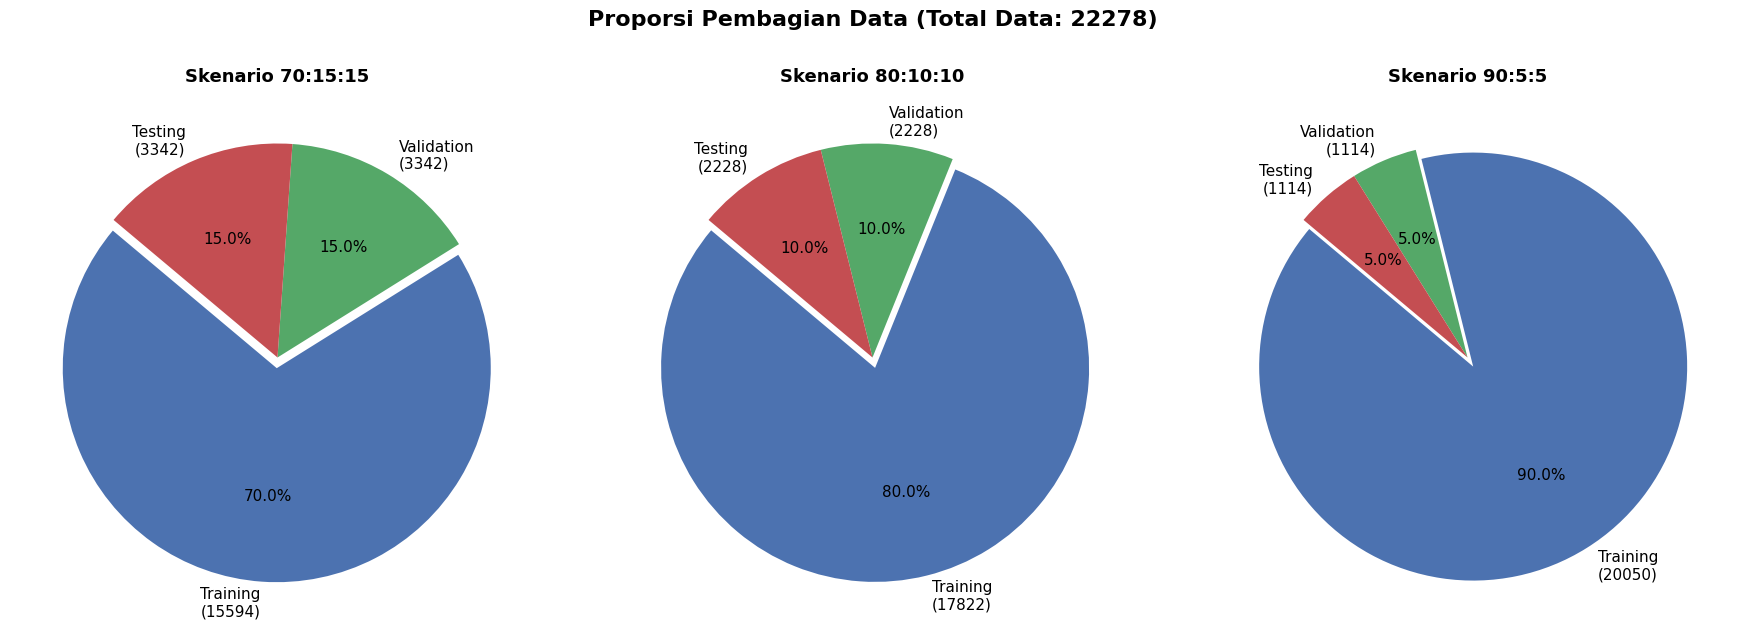

In [ ]:
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# ==========================================
# 1. PROSES DATA SPLITTING
# ==========================================
# Skenario 1: 70:15:15
train_data1, temp_data1 = train_test_split(data, test_size=0.3, random_state=42)
val_data1, test_data1 = train_test_split(temp_data1, test_size=0.5, random_state=42)

# Skenario 2: 80:10:10
train_data2, temp_data2 = train_test_split(data, test_size=0.2, random_state=42)
val_data2, test_data2 = train_test_split(temp_data2, test_size=0.5, random_state=42)

# Skenario 3: 90:5:5
train_data3, temp_data3 = train_test_split(data, test_size=0.1, random_state=42)
val_data3, test_data3 = train_test_split(temp_data3, test_size=0.5, random_state=42)

# ==========================================
# 2. VISUALISASI DENGAN PIE CHART
# ==========================================
def plot_split_pie(train_len, val_len, test_len, judul, ax):
    # Data untuk pie chart
    sizes = [train_len, val_len, test_len]
    labels = [f'Training\n({train_len})', f'Validation\n({val_len})', f'Testing\n({test_len})']

    # Pengaturan warna agar menarik
    colors = ['#4C72B0', '#55A868', '#C44E52']

    # Memberi efek potongan sedikit keluar pada porsi Training
    explode = (0.05, 0, 0)

    # Membuat pie chart di axis yang ditentukan
    ax.pie(sizes, explode=explode, labels=labels, colors=colors,
           autopct='%1.1f%%', startangle=140, textprops={'fontsize': 11})
    ax.set_title(judul, fontweight='bold', fontsize=13)

# Membuat kanvas figure dengan 1 baris dan 3 kolom
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 6))
fig.suptitle(f'Proporsi Pembagian Data (Total Data: {len(data)})',
             fontsize=16, fontweight='bold', y=1.05)

# Plot masing-masing skenario ke dalam subplots
plot_split_pie(len(train_data1), len(val_data1), len(test_data1), 'Skenario 70:15:15', axes[0])
plot_split_pie(len(train_data2), len(val_data2), len(test_data2), 'Skenario 80:10:10', axes[1])
plot_split_pie(len(train_data3), len(val_data3), len(test_data3), 'Skenario 90:5:5', axes[2])

# Merapikan jarak antar grafik dan menampilkannya
plt.tight_layout()
plt.show()


Total Train Data 1 (70%): 15594 baris


/tmp/ipykernel_558/2869165686.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='hard_toxic', ax=axes[0], palette='Blues')
/tmp/ipykernel_558/2869165686.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='hard_polarized', ax=axes[1], palette='Oranges')


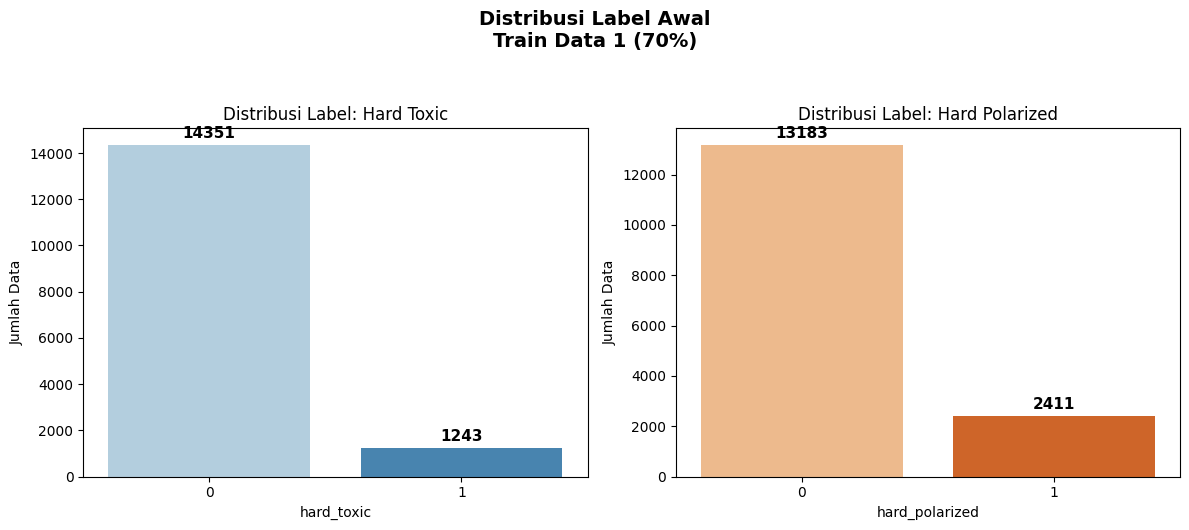


Total Train Data 2 (80%): 17822 baris


/tmp/ipykernel_558/2869165686.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='hard_toxic', ax=axes[0], palette='Blues')
/tmp/ipykernel_558/2869165686.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='hard_polarized', ax=axes[1], palette='Oranges')


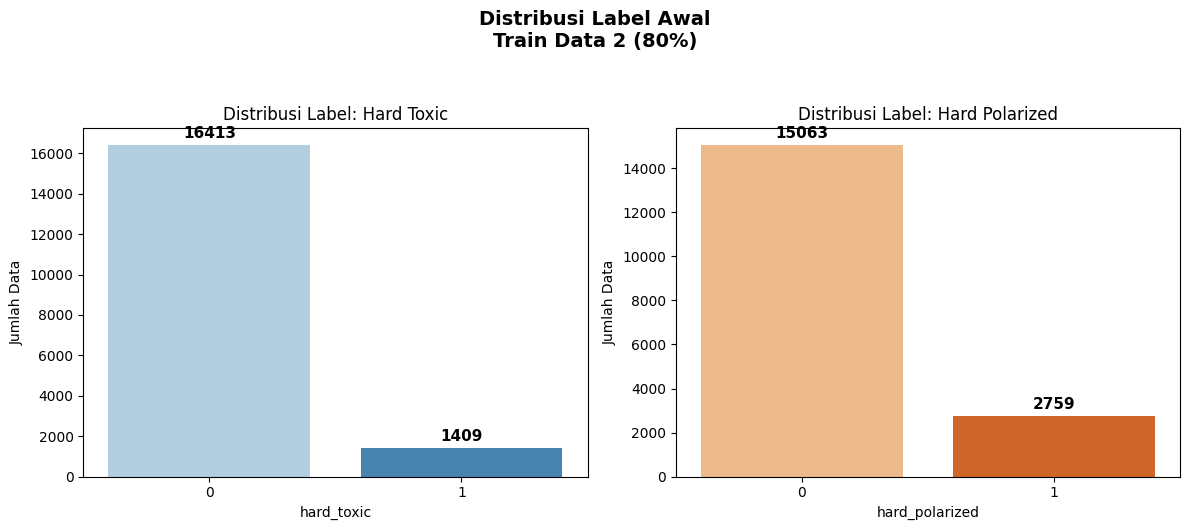


Total Train Data 3 (90%): 20050 baris


/tmp/ipykernel_558/2869165686.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='hard_toxic', ax=axes[0], palette='Blues')
/tmp/ipykernel_558/2869165686.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='hard_polarized', ax=axes[1], palette='Oranges')


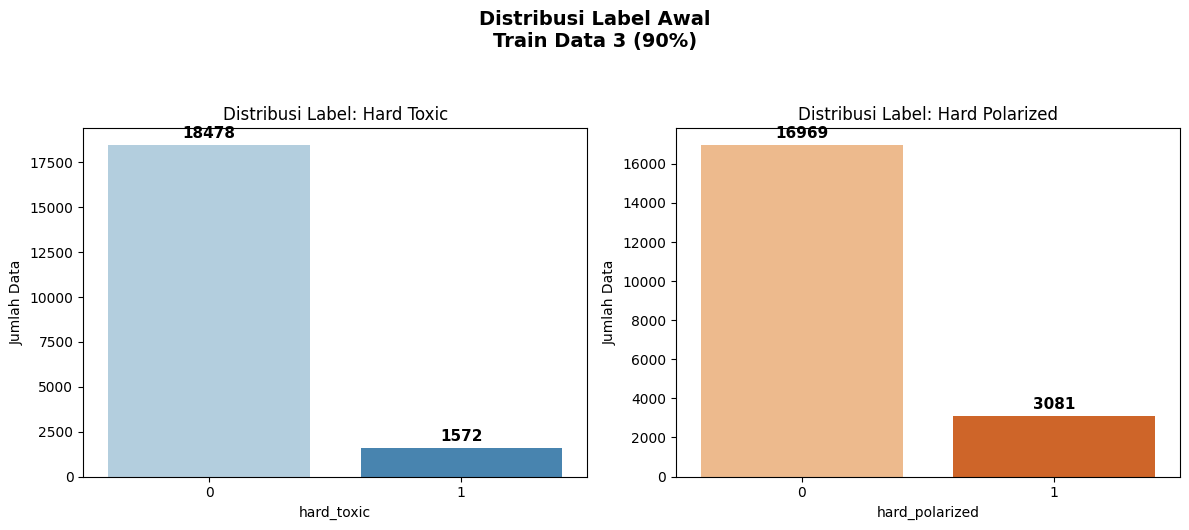

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_distribusi_awal(df, nama_data):
    # Cetak total data
    print(f"\n" + "="*40)
    print(f"Total {nama_data}: {len(df)} baris")
    print("="*40)

    # Membuat figure dengan 1 baris dan 2 kolom
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))
    fig.suptitle(f'Distribusi Label Awal\n{nama_data}', fontsize=14, fontweight='bold', y=1.05)

    # Plot 1: Distribusi Hard Toxic
    sns.countplot(data=df, x='hard_toxic', ax=axes[0], palette='Blues')
    axes[0].set_title('Distribusi Label: Hard Toxic')
    axes[0].set_ylabel('Jumlah Data')

    # Plot 2: Distribusi Hard Polarized
    sns.countplot(data=df, x='hard_polarized', ax=axes[1], palette='Oranges')
    axes[1].set_title('Distribusi Label: Hard Polarized')
    axes[1].set_ylabel('Jumlah Data')

    # Menambahkan angka jumlah data di atas masing-masing batang (bar)
    for ax in axes:
        for p in ax.patches:
            height = p.get_height()
            if height > 0: # Pastikan tinggi bar > 0 agar tidak error
                ax.annotate(f'{int(height)}',
                            (p.get_x() + p.get_width() / 2., height),
                            ha='center', va='bottom',
                            xytext=(0, 3), textcoords='offset points',
                            fontsize=11, fontweight='bold')

    # Merapikan dan menampilkan plot
    plt.tight_layout()
    plt.show()

# ==========================================
# EKSEKUSI UNTUK SEMUA DATA TRAIN
# ==========================================

# 1. Plot Distribusi train_data1 (70%)
plot_distribusi_awal(train_data1, "Train Data 1 (70%)")

# 2. Plot Distribusi train_data2 (80%)
plot_distribusi_awal(train_data2, "Train Data 2 (80%)")

# 3. Plot Distribusi train_data3 (90%)
plot_distribusi_awal(train_data3, "Train Data 3 (90%)")


       PROSES RUS: Data 1 (70%)



/tmp/ipykernel_558/1584974366.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_rus_toxic, x='hard_toxic', ax=axes[0, 0], palette='Blues')
/tmp/ipykernel_558/1584974366.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_rus_toxic, x='hard_polarized', ax=axes[0, 1], palette='Oranges')
/tmp/ipykernel_558/1584974366.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_rus_polarized, x='hard_polarized', ax=axes[1, 0], palette='Oranges')
/tmp/ipykernel_558/1584974366.py:59: FutureWarning: 

Passing `palette` wit

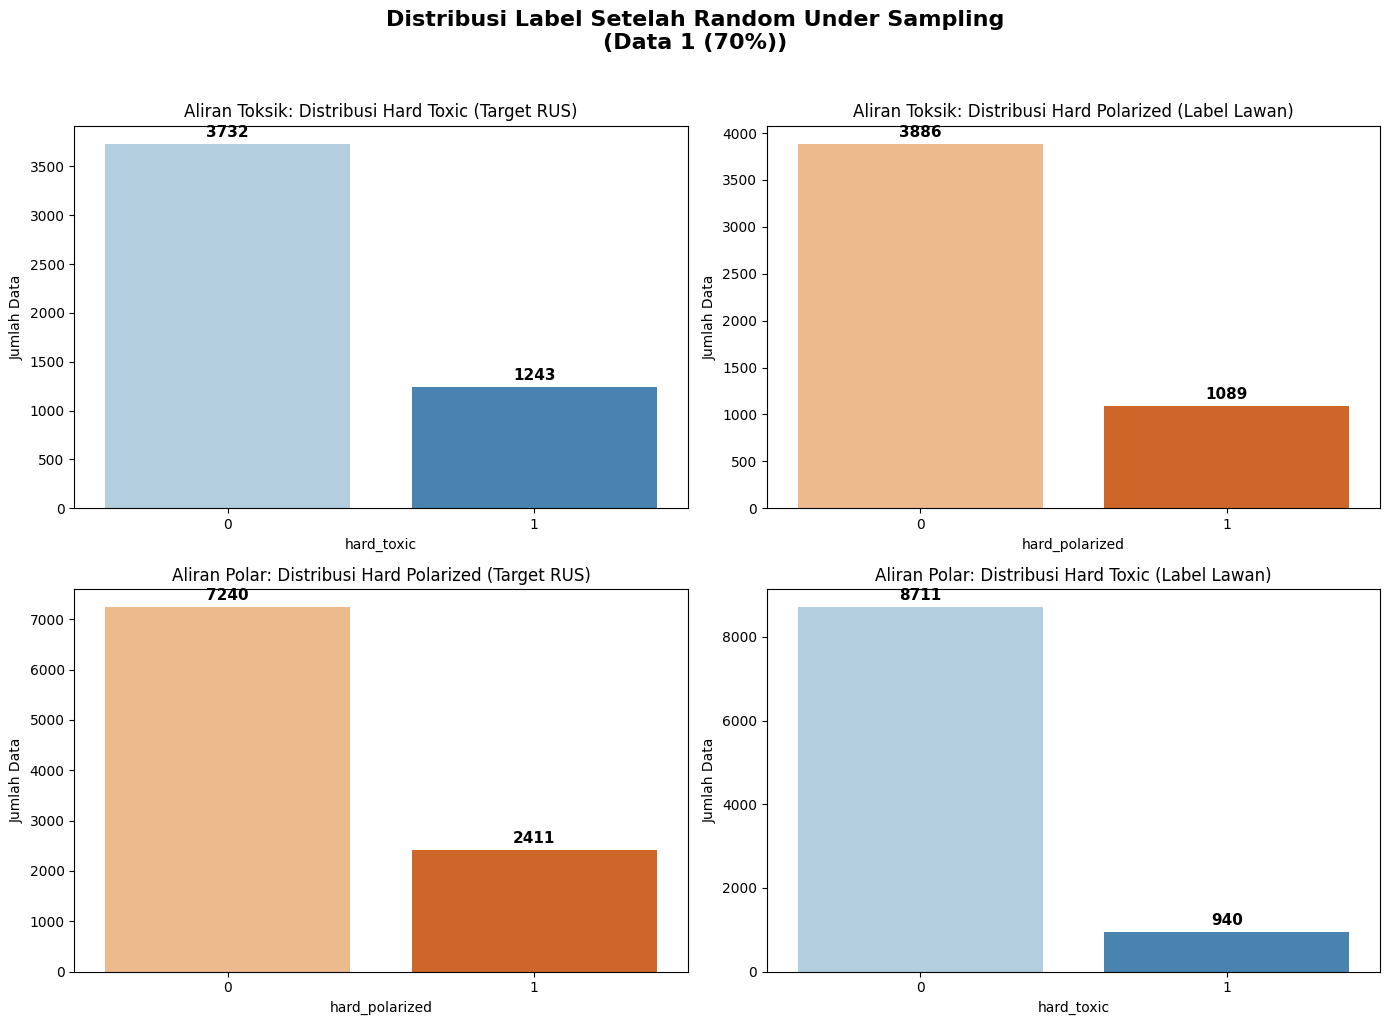


       PROSES RUS: Data 2 (80%)



/tmp/ipykernel_558/1584974366.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_rus_toxic, x='hard_toxic', ax=axes[0, 0], palette='Blues')
/tmp/ipykernel_558/1584974366.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_rus_toxic, x='hard_polarized', ax=axes[0, 1], palette='Oranges')
/tmp/ipykernel_558/1584974366.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_rus_polarized, x='hard_polarized', ax=axes[1, 0], palette='Oranges')
/tmp/ipykernel_558/1584974366.py:59: FutureWarning: 

Passing `palette` wit

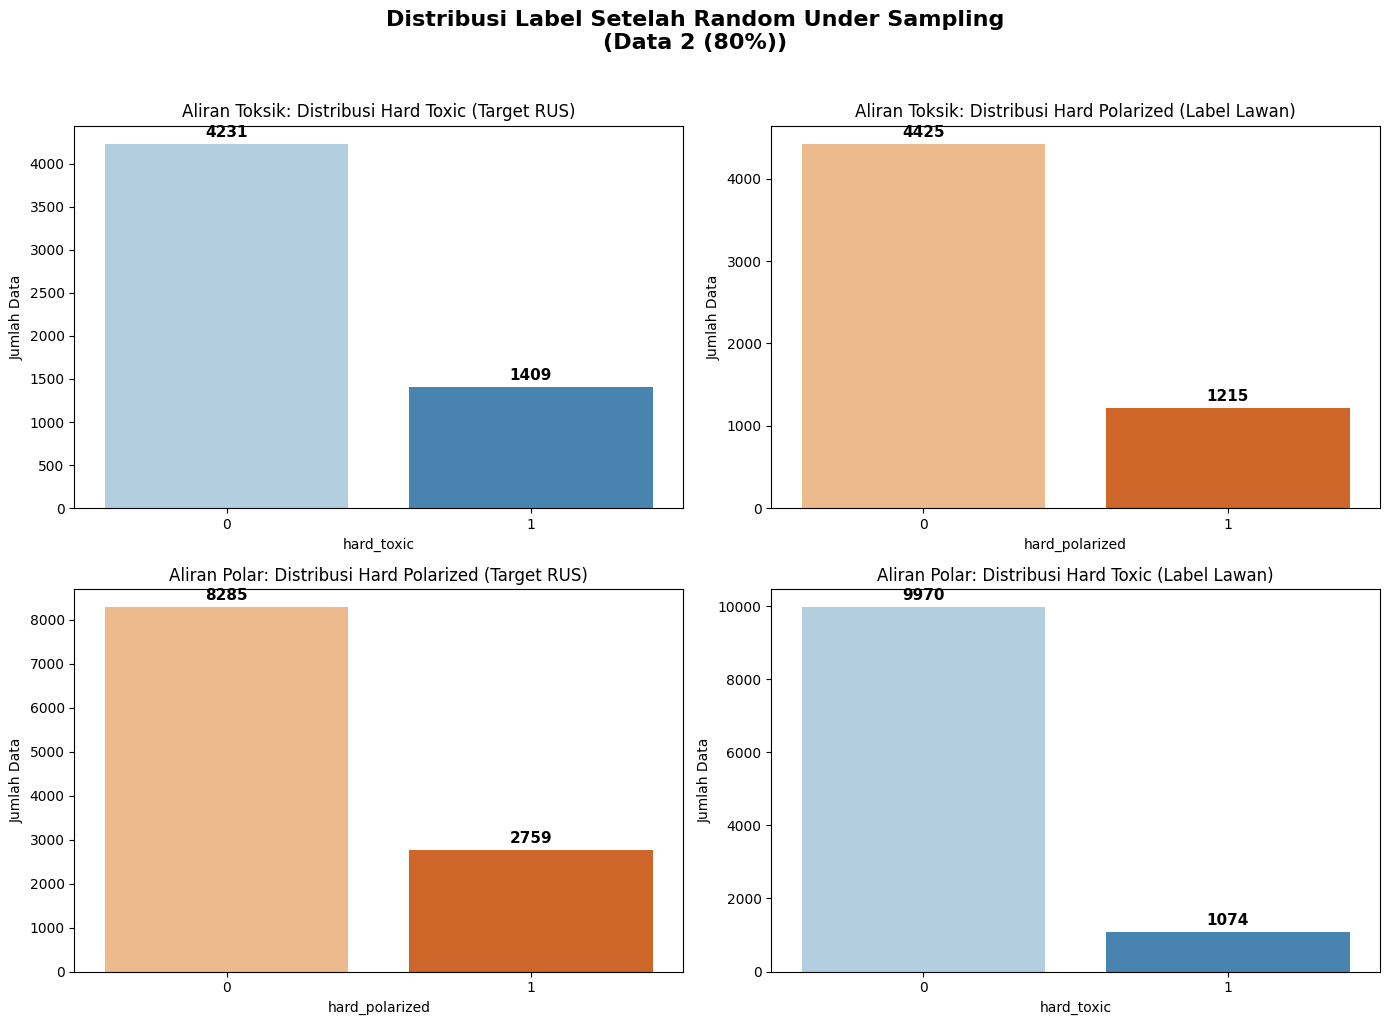


       PROSES RUS: Data 3 (90%)



/tmp/ipykernel_558/1584974366.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_rus_toxic, x='hard_toxic', ax=axes[0, 0], palette='Blues')
/tmp/ipykernel_558/1584974366.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_rus_toxic, x='hard_polarized', ax=axes[0, 1], palette='Oranges')
/tmp/ipykernel_558/1584974366.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_rus_polarized, x='hard_polarized', ax=axes[1, 0], palette='Oranges')
/tmp/ipykernel_558/1584974366.py:59: FutureWarning: 

Passing `palette` wit

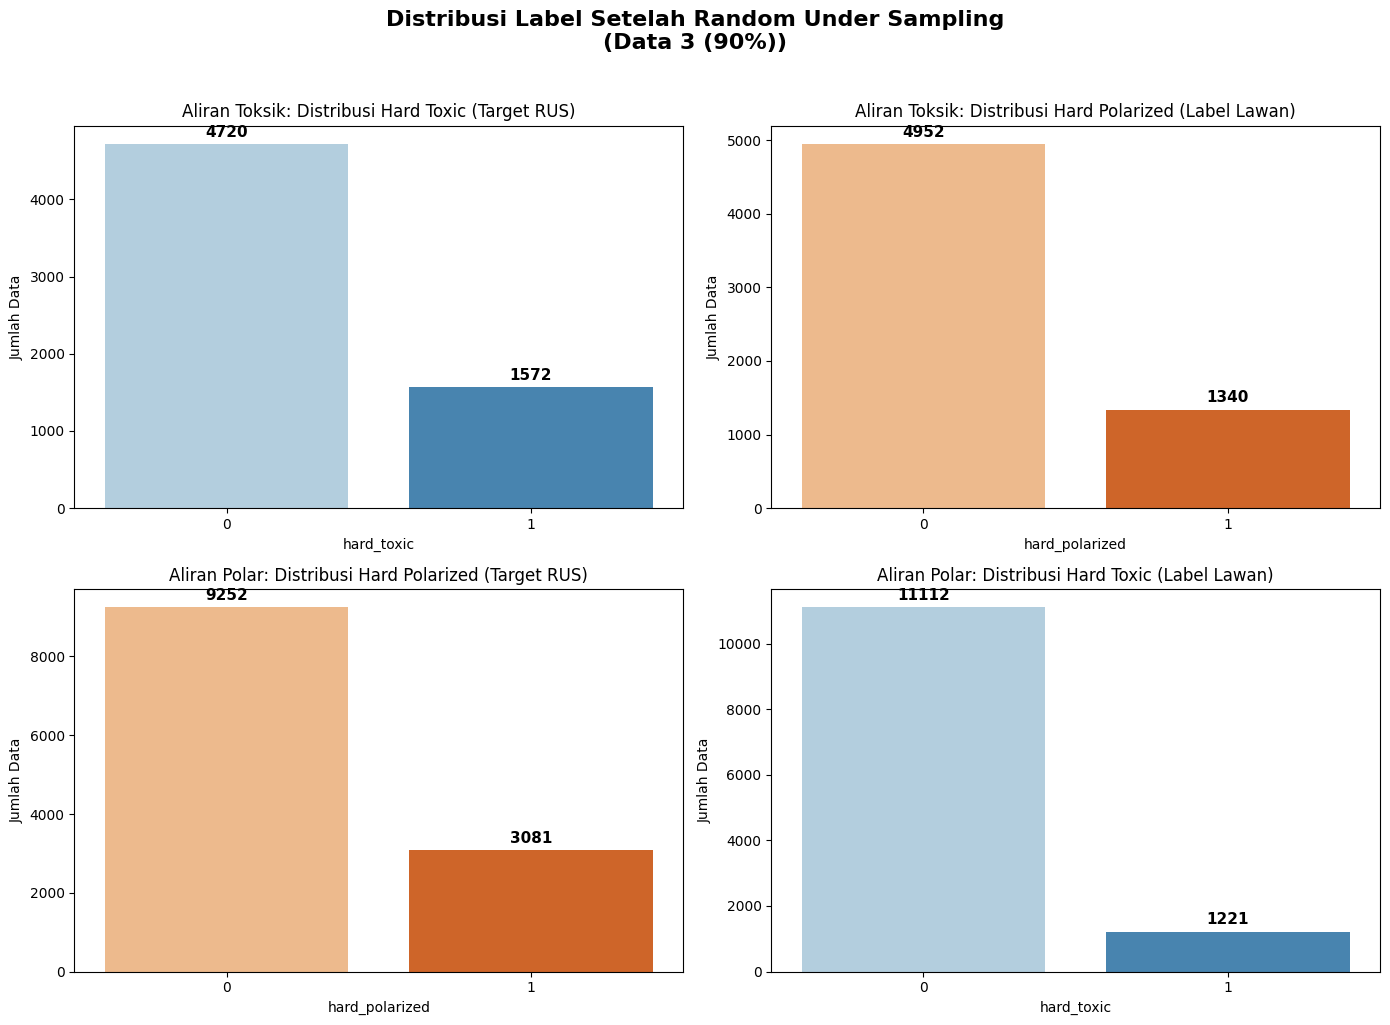

In [ ]:
from imblearn.under_sampling import RandomUnderSampler
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Buat fungsi agar kode tidak perlu ditulis berulang kali daris ganteng muaghhhhh
def proses_rus_multitask(df, nama_data):
    # Strategi 0.333 untuk rasio 1:3
    rus = RandomUnderSampler(sampling_strategy=0.333, random_state=42)

    print(f"\n" + "="*45)
    print(f"       PROSES RUS: {nama_data}")
    print("="*45 + "\n")

    # ==========================================
    # ALIRAN 1: Pemangkasan berdasarkan TOKSIK
    # ==========================================
    X_toxic_input = df.drop(columns=['hard_toxic'])
    y_toxic_target = df['hard_toxic']

    X_res_toxic, y_res_toxic = rus.fit_resample(X_toxic_input, y_toxic_target)

    # Gabungkan kembali utuh 5 kolom
    df_rus_toxic = X_res_toxic.copy()
    df_rus_toxic['hard_toxic'] = y_res_toxic

    # ==========================================
    # ALIRAN 2: Pemangkasan berdasarkan POLARIZED
    # ==========================================
    X_polar_input = df.drop(columns=['hard_polarized'])
    y_polar_target = df['hard_polarized']

    X_res_polar, y_res_polar = rus.fit_resample(X_polar_input, y_polar_target)

    # Gabungkan kembali utuh 5 kolom
    df_rus_polarized = X_res_polar.copy()
    df_rus_polarized['hard_polarized'] = y_res_polar

    # ==========================================
    # VISUALISASI HASIL DISTRIBUSI (BAR CHART)
    # ==========================================
    # Membuat figure dengan 2 baris dan 2 kolom
    fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))
    fig.suptitle(f'Distribusi Label Setelah Random Under Sampling\n({nama_data})', fontsize=16, fontweight='bold', y=1.02)

    # Plot 1: Aliran Toksik (Target RUS: hard_toxic)
    sns.countplot(data=df_rus_toxic, x='hard_toxic', ax=axes[0, 0], palette='Blues')
    axes[0, 0].set_title('Aliran Toksik: Distribusi Hard Toxic (Target RUS)')

    # Plot 2: Aliran Toksik (Label Lawan: hard_polarized)
    sns.countplot(data=df_rus_toxic, x='hard_polarized', ax=axes[0, 1], palette='Oranges')
    axes[0, 1].set_title('Aliran Toksik: Distribusi Hard Polarized (Label Lawan)')

    # Plot 3: Aliran Polar (Target RUS: hard_polarized)
    sns.countplot(data=df_rus_polarized, x='hard_polarized', ax=axes[1, 0], palette='Oranges')
    axes[1, 0].set_title('Aliran Polar: Distribusi Hard Polarized (Target RUS)')

    # Plot 4: Aliran Polar (Label Lawan: hard_toxic)
    sns.countplot(data=df_rus_polarized, x='hard_toxic', ax=axes[1, 1], palette='Blues')
    axes[1, 1].set_title('Aliran Polar: Distribusi Hard Toxic (Label Lawan)')

    # Menambahkan angka di atas masing-masing bar (batang)
    for ax in axes.flat:
        for p in ax.patches:
            height = p.get_height()
            # Hanya tulis angka jika tinggi bar > 0 (mengatasi error NaN/None)
            if height > 0:
                ax.annotate(f'{int(height)}',
                            (p.get_x() + p.get_width() / 2., height),
                            ha='center', va='bottom',
                            xytext=(0, 3), textcoords='offset points',
                            fontsize=11, fontweight='bold')

        # Rapikan label sumbu y
        ax.set_ylabel('Jumlah Data')

    # Merapikan jarak antar grafik dan menampilkannya
    plt.tight_layout()
    plt.show()

    return df_rus_toxic, df_rus_polarized

# ==========================================
# EKSEKUSI UNTUK SEMUA DATA TRAIN
# ==========================================

# 1. Proses train_data1 (70%)
df_train1_rus_toxic, df_train1_rus_polarized = proses_rus_multitask(train_data1, "Data 1 (70%)")

# 2. Proses train_data2 (80%)
df_train2_rus_toxic, df_train2_rus_polarized = proses_rus_multitask(train_data2, "Data 2 (80%)")

# 3. Proses train_data3 (90%)
df_train3_rus_toxic, df_train3_rus_polarized = proses_rus_multitask(train_data3, "Data 3 (90%)")

In [ ]:

print("\n---OVERVIEW DATA PENELITIAN ---")
print("data non rus 1 :",train_data1.shape)
print("data non rus 2 :",train_data2.shape)
print("data non rus 3 :",train_data3.shape)

print("data rus 1 (toxic) :",df_train1_rus_toxic.shape)
print("data rus 2 (toxic) :",df_train2_rus_toxic.shape)
print("data rus 3 (toxic) :",df_train3_rus_toxic.shape)

print("data rus 1 (polarized) :",df_train1_rus_polarized.shape)
print("data rus 2 (polarized) :",df_train2_rus_polarized.shape)
print("data rus 3 (polarized) :",df_train3_rus_polarized.shape)

# perkecil train data 1 untuk testing phase evaluasi dan implementasi jadi 5%


---OVERVIEW DATA PENELITIAN ---
data non rus 1 : (15594, 9)
data non rus 2 : (17822, 9)
data non rus 3 : (20050, 9)
data rus 1 (toxic) : (4975, 9)
data rus 2 (toxic) : (5640, 9)
data rus 3 (toxic) : (6292, 9)
data rus 1 (polarized) : (9651, 9)
data rus 2 (polarized) : (11044, 9)
data rus 3 (polarized) : (12333, 9)


In [ ]:
import os
os.environ["USE_TF"] = "0"
os.environ["USE_TORCH"] = "1"

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score
from transformers import BertForSequenceClassification, BertTokenizer, AutoConfig
from torch.optim import AdamW
import ast

# 1. Setup Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Menggunakan device: {device}")

# 2. Class Dataset PyTorch (Sudah diperbaiki untuk menghilangkan UserWarning)
class ToxicityDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels, soft_labels):
        self.encodings = encodings
        self.labels = [int(label) for label in labels]

        bersih_soft_labels = []
        for s_label in soft_labels:
            if isinstance(s_label, str) and s_label.startswith('['):
                s_label = ast.literal_eval(s_label)

            if isinstance(s_label, (list, tuple, np.ndarray)):
                nilai_positif = float(s_label[0])
                bersih_soft_labels.append(nilai_positif)
            else:
                bersih_soft_labels.append(float(s_label))

        self.soft_labels = bersih_soft_labels

    def __getitem__(self, idx):
        # Pakai .clone().detach() agar PyTorch tidak komplain soal copy tensor
        item = {key: val[idx].clone().detach() for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        item['soft_labels'] = torch.tensor(self.soft_labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

# 3. Custom Loss: LDL4C (MAE + Entropy Weighting + Large Margin)
class LDL4CLoss(nn.Module):
    def __init__(self, rho=0.1, C1=1.0):
        super(LDL4CLoss, self).__init__()
        self.rho = rho
        self.C1 = C1

    def forward(self, probs, soft_labels, hard_labels):
        # 1. Entropy (Pemberatan)
        entropy = -torch.sum(soft_labels * torch.log(soft_labels + 1e-9), dim=1)

        # 2. MAE berbobot
        mae = torch.sum(torch.abs(probs - soft_labels), dim=1)
        weighted_mae = torch.mean(entropy * mae)

        # 3. Large Margin
        prob_target = probs.gather(1, hard_labels.unsqueeze(1)).squeeze(1)

        mask = F.one_hot(hard_labels, num_classes=probs.size(1)).bool()
        probs_other = probs.masked_fill(mask, -1.0)
        prob_other_max = probs_other.max(dim=1)[0]

        alpha = prob_target - prob_other_max
        margin_loss = F.relu(1.0 - (alpha / self.rho))
        avg_margin_loss = torch.mean(margin_loss)

        total_loss = weighted_mae + (self.C1 * avg_margin_loss)
        return total_loss

# 4. Fungsi Utama
def train_pure_pytorch(df_train, df_val, df_test, task="polar", model_path="indolem/indobertweet-base-uncased", output_dir="./hasil_pytorch_indobertweet"):
    os.makedirs(output_dir, exist_ok=True)

    soft_label_col = 'soft_toxic' if task == 'toxic' else 'soft_polarized'

    train_texts, train_labels, train_softs = df_train['text'].tolist(), df_train['label'].tolist(), df_train[soft_label_col].tolist()
    val_texts, val_labels, val_softs       = df_val['text'].tolist(), df_val['label'].tolist(), df_val[soft_label_col].tolist()
    test_texts, test_labels, test_softs    = df_test['text'].tolist(), df_test['label'].tolist(), df_test[soft_label_col].tolist()

    epochs = 3
    batch_size = 16

    print(f"{'='*50}")
    print(f"🚀 MEMULAI TRAINING LDL4C (TASK: {task.upper()})")
    print(f"Jumlah Data Latih (Train) : {len(train_texts)}")
    print(f"{'='*50}")

    tokenizer = BertTokenizer.from_pretrained(model_path)

    train_encodings = tokenizer(train_texts, truncation=True, padding=True, max_length=128, return_tensors='pt')
    val_encodings   = tokenizer(val_texts, truncation=True, padding=True, max_length=128, return_tensors='pt')
    test_encodings  = tokenizer(test_texts, truncation=True, padding=True, max_length=128, return_tensors='pt')

    train_dataset = ToxicityDataset(train_encodings, train_labels, train_softs)
    val_dataset   = ToxicityDataset(val_encodings, val_labels, val_softs)
    test_dataset  = ToxicityDataset(test_encodings, test_labels, test_softs)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(val_dataset, batch_size=16, shuffle=False)
    test_loader  = DataLoader(test_dataset, batch_size=16, shuffle=False)

    config = AutoConfig.from_pretrained(model_path)
    config.num_labels = 2
    config.id2label = {0: "LABEL_NEGATIVE", 1: "LABEL_POSITIVE"}
    config.label2id = {"LABEL_NEGATIVE": 0, "LABEL_POSITIVE": 1}

    model = BertForSequenceClassification.from_pretrained(model_path, config=config, ignore_mismatched_sizes=True)
    model.to(device)

    optimizer = AdamW(model.parameters(), lr=1e-5)

    # --- MENGGUNAKAN CUSTOM LOSS ---
    # rho = 0.1 dan C1 = 1.0 (Bisa kamu tuning nanti jika diperlukan)
    loss_fn = LDL4CLoss(rho=0.1, C1=1.0)

    for epoch in range(epochs):
        print(f"\n--- Epoch {epoch + 1}/{epochs} ---")

        # 1. FASE TRAINING
        model.train()
        total_train_loss = 0
        train_preds = []
        train_targets = []

        for batch in train_loader:
            optimizer.zero_grad()

            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            b_labels = batch['labels'].to(device).long() # Hard Label
            b_soft_labels = batch['soft_labels'].to(device) # Probabilitas kelas positif

            outputs = model(input_ids, attention_mask=attention_mask)
            logits = outputs.logits

            probs = F.softmax(logits, dim=1)

            # Susun soft label jadi [Prob_Negatif, Prob_Positif]
            targets = torch.stack([1.0 - b_soft_labels, b_soft_labels], dim=1).float()

            # Masukkan ke Custom Loss (butuh probs, soft labels, dan hard labels)
            loss = loss_fn(probs, targets, b_labels)
            total_train_loss += loss.item()

            loss.backward()
            optimizer.step()

            preds = torch.argmax(probs, dim=1)
            train_preds.extend(preds.cpu().numpy())
            train_targets.extend(b_labels.cpu().numpy())

        avg_train_loss = total_train_loss / len(train_loader)
        train_accuracy = accuracy_score(train_targets, train_preds)

        # 2. FASE VALIDASI
        model.eval()
        total_val_loss = 0
        val_preds = []
        val_targets = []

        with torch.no_grad():
            for batch in val_loader:
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                b_labels = batch['labels'].to(device).long()
                b_soft_labels = batch['soft_labels'].to(device)

                outputs = model(input_ids, attention_mask=attention_mask)
                logits = outputs.logits

                probs = F.softmax(logits, dim=1)

                targets = torch.stack([1.0 - b_soft_labels, b_soft_labels], dim=1).float()

                loss = loss_fn(probs, targets, b_labels)
                total_val_loss += loss.item()

                preds = torch.argmax(probs, dim=1)
                val_preds.extend(preds.cpu().numpy())
                val_targets.extend(b_labels.cpu().numpy())

        avg_val_loss = total_val_loss / len(val_loader)
        val_accuracy = accuracy_score(val_targets, val_preds)

        print(f"Train Loss (LDL4C): {avg_train_loss:.4f} | Train Acc: {train_accuracy:.4f}")
        print(f"Val Loss (LDL4C)  : {avg_val_loss:.4f} | Val Acc  : {val_accuracy:.4f}")

    # ==========================
    # EVALUASI AKHIR PADA TEST SET
    # ==========================
    print(f"\n{'-'*50}")
    print("Menghitung Metrik Evaluasi Akhir pada Data Test...")

    model.eval()
    all_preds = []
    all_labels = []
    all_probs = []
    all_softs = []

    with torch.no_grad():
        for batch in test_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            b_labels = batch['labels'].to(device).long()
            b_soft_labels = batch['soft_labels'].to(device)

            outputs = model(input_ids, attention_mask=attention_mask)
            logits = outputs.logits

            probs = F.softmax(logits, dim=1)
            preds = torch.argmax(probs, dim=1)

            pos_probs = probs[:, 1]

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(b_labels.cpu().numpy())
            all_probs.extend(pos_probs.cpu().numpy())
            all_softs.extend(b_soft_labels.cpu().numpy())

    try:
        roc_auc = roc_auc_score(all_labels, all_probs)
    except ValueError:
        roc_auc = 0.5

    all_probs_np = np.array(all_probs)
    all_softs_np = np.array(all_softs)

    mae_pos = np.abs(all_probs_np - all_softs_np)
    mae_neg = np.abs((1.0 - all_probs_np) - (1.0 - all_softs_np))
    final_mae = np.mean((mae_pos + mae_neg) / 2)

    unik, jumlah = np.unique(all_preds, return_counts=True)
    print("\n--- Analisis Tebakan Model ---")
    print(f"Distribusi tebakan model pada Data Test: {dict(zip(unik, jumlah))}")
    print("------------------------------\n")

    metrics = {
        'accuracy': accuracy_score(all_labels, all_preds),
        'macro_f1': f1_score(all_labels, all_preds, average='macro'),
        'precision': precision_score(all_labels, all_preds, average='macro'),
        'recall': recall_score(all_labels, all_preds, average='macro'),
        'roc_auc': roc_auc,
        'mae_soft_label': final_mae
    }

    print(f"Hasil Evaluasi Test Akhir:")
    for key, value in metrics.items():
        print(f"- {key}: {value:.4f}")

    model.save_pretrained(output_dir)
    tokenizer.save_pretrained(output_dir)
    pd.DataFrame([metrics]).to_csv(os.path.join(output_dir, "test_performance.csv"), index=False)

    print("\n🎉 Training selesai! Semua hasil tersimpan di:", output_dir)

Menggunakan device: cuda


In [ ]:
import pandas as pd

# Pastikan nama kolom target sudah 'label', kalau belum di-rename dulu
# We use 'hard_polarized' as the 'label' for the model's hard target
# And 'soft_polarized' as the soft label distribution.
df_train = df_train1_rus_polarized.rename(columns={"hard_polarized": "label"})
df_test = test_data1.rename(columns={"hard_polarized": "label"})
df_val = val_data1.rename(columns={"hard_polarized": "label"})

# Jalankan fungsinya
train_pure_pytorch(df_train, df_val, df_test)

🚀 MEMULAI TRAINING LDL4C (TASK: POLAR)
Jumlah Data Latih (Train) : 9651


tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/235k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.10k [00:00<?, ?B/s]

...

[transformers] BertForSequenceClassification LOAD REPORT from: indolem/indobertweet-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


model.safetensors:   0%|          | 0.00/445M [00:00<?, ?B/s]


--- Epoch 1/3 ---
Train Loss (LDL4C): 0.6294 | Train Acc: 0.7540
Val Loss (LDL4C)  : 0.3999 | Val Acc  : 0.8423

--- Epoch 2/3 ---
Train Loss (LDL4C): 0.6005 | Train Acc: 0.7654
Val Loss (LDL4C)  : 0.4094 | Val Acc  : 0.8369

--- Epoch 3/3 ---
Train Loss (LDL4C): 0.5115 | Train Acc: 0.7931
Val Loss (LDL4C)  : 0.3806 | Val Acc  : 0.8426

--------------------------------------------------
Menghitung Metrik Evaluasi Akhir pada Data Test...

--- Analisis Tebakan Model ---
Distribusi tebakan model pada Data Test: {np.int64(0): np.int64(2992), np.int64(1): np.int64(350)}
------------------------------

Hasil Evaluasi Test Akhir:
- accuracy: 0.8456
- macro_f1: 0.6591
- precision: 0.6955
- recall: 0.6395
- roc_auc: 0.8412
- mae_soft_label: 0.3863


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


🎉 Training selesai! Semua hasil tersimpan di: ./hasil_pytorch_indobertweet


In [ ]:
# Pastikan nama kolom target sudah 'label', kalau belum di-rename dulu
df_train = df_train2_rus_polarized.rename(columns={"hard_polarized": "label"})
df_test = test_data2.rename(columns={"hard_polarized": "label"})
df_val = val_data2.rename(columns={"hard_polarized": "label"})

# Jalankan fungsinya
train_pure_pytorch(df_train, df_val, df_test)

🚀 MEMULAI TRAINING LDL4C (TASK: POLAR)
Jumlah Data Latih (Train) : 11044


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: indolem/indobertweet-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



--- Epoch 1/3 ---
Train Loss (LDL4C): 0.6264 | Train Acc: 0.7600
Val Loss (LDL4C)  : 0.4024 | Val Acc  : 0.8330

--- Epoch 2/3 ---
Train Loss (LDL4C): 0.5228 | Train Acc: 0.7897
Val Loss (LDL4C)  : 0.5948 | Val Acc  : 0.7374

--- Epoch 3/3 ---
Train Loss (LDL4C): 0.4795 | Train Acc: 0.8021
Val Loss (LDL4C)  : 0.4415 | Val Acc  : 0.8276

--------------------------------------------------
Menghitung Metrik Evaluasi Akhir pada Data Test...

--- Analisis Tebakan Model ---
Distribusi tebakan model pada Data Test: {np.int64(0): np.int64(1841), np.int64(1): np.int64(387)}
------------------------------

Hasil Evaluasi Test Akhir:
- accuracy: 0.8326
- macro_f1: 0.6886
- precision: 0.6773
- recall: 0.7037
- roc_auc: 0.8412
- mae_soft_label: 0.3814


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


🎉 Training selesai! Semua hasil tersimpan di: ./hasil_pytorch_indobertweet


In [ ]:
# Pastikan nama kolom target sudah 'label', kalau belum di-rename dulu
df_train = df_train3_rus_polarized.rename(columns={"hard_polarized": "label"})
df_test = test_data3.rename(columns={"hard_polarized": "label"})
df_val = val_data3.rename(columns={"hard_polarized": "label"})

# Jalankan fungsinya
train_pure_pytorch(df_train, df_val, df_test)

🚀 MEMULAI TRAINING LDL4C (TASK: POLAR)
Jumlah Data Latih (Train) : 12333


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: indolem/indobertweet-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



--- Epoch 1/3 ---
Train Loss (LDL4C): 0.6084 | Train Acc: 0.7598
Val Loss (LDL4C)  : 0.4093 | Val Acc  : 0.8420

--- Epoch 2/3 ---
Train Loss (LDL4C): 0.5177 | Train Acc: 0.7958
Val Loss (LDL4C)  : 0.3646 | Val Acc  : 0.8537

--- Epoch 3/3 ---
Train Loss (LDL4C): 0.4860 | Train Acc: 0.8042
Val Loss (LDL4C)  : 0.3933 | Val Acc  : 0.8375

--------------------------------------------------
Menghitung Metrik Evaluasi Akhir pada Data Test...

--- Analisis Tebakan Model ---
Distribusi tebakan model pada Data Test: {np.int64(0): np.int64(967), np.int64(1): np.int64(147)}
------------------------------

Hasil Evaluasi Test Akhir:
- accuracy: 0.8312
- macro_f1: 0.6639
- precision: 0.6807
- recall: 0.6521
- roc_auc: 0.8316
- mae_soft_label: 0.3862


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


🎉 Training selesai! Semua hasil tersimpan di: ./hasil_pytorch_indobertweet


In [ ]:
# Pastikan nama kolom target sudah 'label', kalau belum di-rename dulu
df_train = train_data1.rename(columns={"hard_polarized": "label"})
df_test = test_data1.rename(columns={"hard_polarized": "label"})
df_val = val_data1.rename(columns={"hard_polarized": "label"})

# Jalankan fungsinya
train_pure_pytorch(df_train, df_val, df_test)

🚀 MEMULAI TRAINING LDL4C (TASK: POLAR)
Jumlah Data Latih (Train) : 15594


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: indolem/indobertweet-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



--- Epoch 1/3 ---
Train Loss (LDL4C): 0.4531 | Train Acc: 0.8323
Val Loss (LDL4C)  : 0.3752 | Val Acc  : 0.8438

--- Epoch 2/3 ---
Train Loss (LDL4C): 0.3934 | Train Acc: 0.8473
Val Loss (LDL4C)  : 0.3755 | Val Acc  : 0.8477

--- Epoch 3/3 ---
Train Loss (LDL4C): 0.3620 | Train Acc: 0.8601
Val Loss (LDL4C)  : 0.3723 | Val Acc  : 0.8513

--------------------------------------------------
Menghitung Metrik Evaluasi Akhir pada Data Test...

--- Analisis Tebakan Model ---
Distribusi tebakan model pada Data Test: {np.int64(0): np.int64(3152), np.int64(1): np.int64(190)}
------------------------------

Hasil Evaluasi Test Akhir:
- accuracy: 0.8522
- macro_f1: 0.6108
- precision: 0.7189
- recall: 0.5893
- roc_auc: 0.8450
- mae_soft_label: 0.3741


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


🎉 Training selesai! Semua hasil tersimpan di: ./hasil_pytorch_indobertweet


In [ ]:
# Pastikan nama kolom target sudah 'label', kalau belum di-rename dulu
df_train = train_data2.rename(columns={"hard_polarized": "label"})
df_test = test_data2.rename(columns={"hard_polarized": "label"})
df_val = val_data2.rename(columns={"hard_polarized": "label"})

# Jalankan fungsinya
train_pure_pytorch(df_train, df_val, df_test)

🚀 MEMULAI TRAINING LDL4C (TASK: POLAR)
Jumlah Data Latih (Train) : 17822


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: indolem/indobertweet-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



--- Epoch 1/3 ---
Train Loss (LDL4C): 0.4589 | Train Acc: 0.8316
Val Loss (LDL4C)  : 0.4492 | Val Acc  : 0.8420

--- Epoch 2/3 ---
Train Loss (LDL4C): 0.3941 | Train Acc: 0.8460
Val Loss (LDL4C)  : 0.3820 | Val Acc  : 0.8496

--- Epoch 3/3 ---
Train Loss (LDL4C): 0.3630 | Train Acc: 0.8582
Val Loss (LDL4C)  : 0.4166 | Val Acc  : 0.8447

--------------------------------------------------
Menghitung Metrik Evaluasi Akhir pada Data Test...

--- Analisis Tebakan Model ---
Distribusi tebakan model pada Data Test: {np.int64(0): np.int64(2109), np.int64(1): np.int64(119)}
------------------------------

Hasil Evaluasi Test Akhir:
- accuracy: 0.8649
- macro_f1: 0.6243
- precision: 0.7423
- recall: 0.5981
- roc_auc: 0.8513
- mae_soft_label: 0.3602


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


🎉 Training selesai! Semua hasil tersimpan di: ./hasil_pytorch_indobertweet


In [21]:
# Pastikan nama kolom target sudah 'label', kalau belum di-rename dulu
df_train = train_data3.rename(columns={"hard_polarized": "label"})
df_test = test_data3.rename(columns={"hard_polarized": "label"})
df_val = val_data3.rename(columns={"hard_polarized": "label"})

# Jalankan fungsinya
train_pure_pytorch(df_train, df_val, df_test)

🚀 MEMULAI TRAINING LDL4C (TASK: POLAR)
Jumlah Data Latih (Train) : 20050


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: indolem/indobertweet-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



--- Epoch 1/3 ---
Train Loss (LDL4C): 0.4522 | Train Acc: 0.8336
Val Loss (LDL4C)  : 0.5505 | Val Acc  : 0.8384

--- Epoch 2/3 ---
Train Loss (LDL4C): 0.3949 | Train Acc: 0.8478
Val Loss (LDL4C)  : 0.3597 | Val Acc  : 0.8537

--- Epoch 3/3 ---
Train Loss (LDL4C): 0.3577 | Train Acc: 0.8579
Val Loss (LDL4C)  : 0.4876 | Val Acc  : 0.8447

--------------------------------------------------
Menghitung Metrik Evaluasi Akhir pada Data Test...

--- Analisis Tebakan Model ---
Distribusi tebakan model pada Data Test: {np.int64(0): np.int64(1098), np.int64(1): np.int64(16)}
------------------------------

Hasil Evaluasi Test Akhir:
- accuracy: 0.8411
- macro_f1: 0.5072
- precision: 0.7346
- recall: 0.5244
- roc_auc: 0.8181
- mae_soft_label: 0.3561


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


🎉 Training selesai! Semua hasil tersimpan di: ./hasil_pytorch_indobertweet
